In [177]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge, LinearRegression
import pandas as pd
import os
%matplotlib inline

In [4]:
os.chdir("/home/thappe/HeaT")

from HeaT.dyn_decomp import *

In [5]:
data_path = "/home/thappe/data/"

In [6]:
ls /home/thappe/data/ 

1940-2023_T2M_era5_westEU_JJAS.nc
1940-2023_T2M_westEU_JJA_LENTISGRID.nc
1940-2023_T2M_westEU_JJA.nc
1940-2023_T2M_westEU_JJAS_LENTISGRID.nc
1940-2023_T2M_westEU_June23-JA-Sept7_LENTISGRID.nc
2023_stream_500hPa_0.25degr_JJAS_westEUext.nc
ERA5_land_sea_mask_WestEU_lentisgrid.nc
gridarea_westEU_lentisgrid.nc
heatwaves/
LENTIS_gridarea_europeWest.nc
LinRegrDetrendedperGridpoint_MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc
MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc*
NASA_GMST.csv
STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc
STREAM500_era5_ExtendedWestEU_0.25degr_1940_2023_JJAS.nc
STREAM500_era5_ExtendedWestEU_0.25degr_1940_2023_June23-JA-Sept7.nc
T2M_decomposition/


# Detrending linearly using GMST

In [5]:
T2M_file = "1940-2023_T2M_westEU_JJA.nc"
t2m = xr.open_dataset(f"{data_path}{T2M_file}")["t2m"] - 273.15



<AxesSubplot:xlabel='Year'>

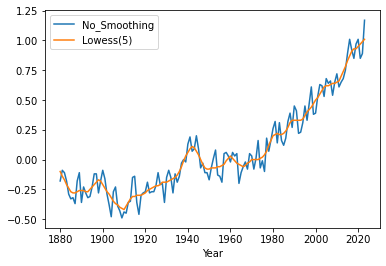

In [6]:
yearly_GMST = pd.read_csv(f"{data_path}NASA_GMST.csv", delimiter=";", skiprows=1, index_col=0)
yearly_GMST.plot()

In [30]:
###GMST###
ny = 2023 - 1940 + 1 
LOWESS5y_yearly_GMST = yearly_GMST["Lowess(5)"][-ny:].to_numpy() ## select correct timeperiod
NoSmooth_yearly_GMST= yearly_GMST["No_Smoothing"][-ny:].to_numpy()
GMST_reshaped = np.empty(92*ny,) #empty array with shape of number of days (e.g 92 per summer, per year)
for i, GMST in enumerate(LOWESS5y_yearly_GMST): ## loop over the GMST data to fill the array
    year_array = np.array(92 * [GMST], dtype=float)
    GMST_reshaped[i*92:(i+1)*92] = year_array[:]
#create xarray 
GMST_xr = xr.DataArray(
    data=GMST_reshaped,
    dims=["time"],
    coords=dict(
        time=t2m.time.dt.year,),
    attrs=dict(
        description="Global Mean Surface Temperature anomalie from NASA, 5 year LOWESS",
        units="degC",),)

In [31]:
from sklearn.linear_model import LinearRegression


x = np.arange(1940,2024,1).reshape(-1,1) #get the years 
y = LOWESS5y_yearly_GMST #get the data
reg = LinearRegression().fit(x, y) #fit the regressor

reg_coefs_5y = reg.coef_[0] #save the coef in the array
print(reg_coefs_5y) 

y = NoSmooth_yearly_GMST #get the data
reg = LinearRegression().fit(x, y) #fit the regressor

reg_coefs_nosmooth = reg.coef_[0] #save the coef in the array
print(reg_coefs_nosmooth) #per year temperature trend

0.012635618102662753
0.01254368735445986


Text(0.5, 0, 'Temp in degr C')

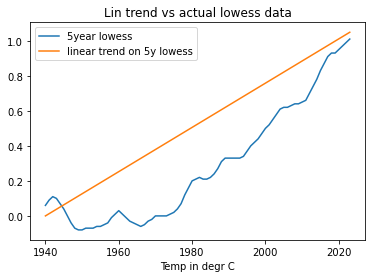

In [33]:
plt.plot(x, LOWESS5y_yearly_GMST, label="5year lowess")
plt.plot(x, np.arange(0,84, 1)*reg_coefs_5y, label="linear trend on 5y lowess")
#plt.plot(x, np.arange(0,84, 1)*reg_coefs_nosmooth, label="linear trend on raw")

plt.title("Lin trend vs actual lowess data")
plt.legend()
plt.xlabel("Temp in degr C")

In [55]:
lin_trend_per_year = np.arange(0,84, 1)*reg_coefs_5y
lin_trend_per_year_reshaped = np.empty(92*ny,) #empty array with shape of number of days (e.g 92 per summer, per year)
for i, trend in enumerate(lin_trend_per_year): ## loop over the GMST data to fill the array
    year_array = np.array(92 * [trend], dtype=float)
    lin_trend_per_year_reshaped[i*92:(i+1)*92] = year_array[:]

lin_trend_per_year_xr = xr.DataArray(
    data=lin_trend_per_year_reshaped,
    dims=["time"],
    coords=dict(
        time=t2m.time,), #.dt.year
    attrs=dict(
        description="Trend",
        units="degC",),)

In [57]:
t2m_detrended_lin_GMST = t2m - lin_trend_per_year_xr

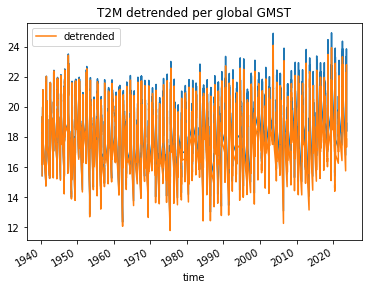

In [68]:
t2m.mean(dim=("latitude", "longitude")).plot()
t2m_detrended_lin_GMST.mean(dim=("latitude", "longitude")).plot(label="detrended")

plt.title("T2M detrended per global GMST")
plt.legend()

# To read in the decomposed t2m data 

In [7]:
t2m_decomped_file = "T2M_westEU_LENTIS=True_decomposed_1940-2022_window=20_CV=False_alpha=10.nc"

In [10]:
t2m_decom = xr.open_dataset(f"{data_path}/T2M_decomposition/JJA/{t2m_decomped_file}")

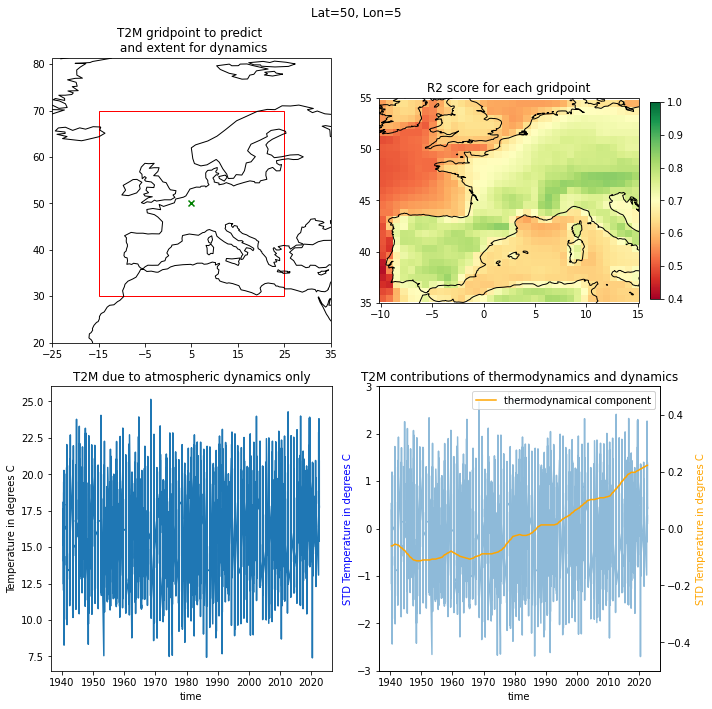

In [71]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches


lon, lat = 5, 50
window=20
lon_bounds = (lon-window, lon+window)
lat_bounds = (lat-window, lat+window)


### PLOT

fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(6, 6)

ax1 = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
ax1.set_extent([lon-(window+10), lon+(window+10), lat-(window+10), lat+(window+10)])
ax1.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
ax1.coastlines()
ax1.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x')
ax1.set_title("T2M gridpoint to predict \n and extent for dynamics")
ax1.set_xticks(np.arange(lon-(window+10), lon+(window+10+1), 10))
ax1.set_yticks(np.arange(lat-(window+10), lat+(window+10+1), 10))


####

ax2 = fig.add_subplot(gs[0:3, 3:6], projection=ccrs.PlateCarree())
pc = ax2.pcolormesh(t2m_decom["R2"].longitude,t2m_decom["R2"].latitude,t2m_decom["R2"].values,
                    vmin=0.4, vmax=1, cmap="RdYlGn")
fig.colorbar(pc, ax=ax2, fraction=0.035, pad=0.04)
ax2.coastlines()
ax2.set_title("R2 score for each gridpoint")
ax2.set_xticks(np.arange(-10, 16, 5))
ax2.set_yticks(np.arange(35, 56, 5))

ax3 = fig.add_subplot(gs[3:6, 0:3])
ax3.plot(t2m_decom["T2M_dynamic"].time, t2m_decom["T2M_dynamic"].sel(latitude=lat, longitude=lon, method="nearest"))
ax3.set_title("T2M due to atmospheric dynamics only")
ax3.set_xlabel("time")
ax3.set_ylabel("Temperature in degrees C")



ax4 = fig.add_subplot(gs[3:6, 3:6])
ax5 = ax4.twinx()
ax4.plot(t2m_decom["T2M_dynamical_std"].time, t2m_decom["T2M_dynamical_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="dynamical component", alpha=0.5)
ax5.plot(t2m_decom["T2M_thermodynamic_std"].time, t2m_decom["T2M_thermodynamic_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="thermodynamical component", c="orange")

ax4.set_title("T2M contributions of thermodynamics and dynamics")
ax4.set_xlabel("time")
ax4.set_ylabel("STD Temperature in degrees C", c="blue")
ax5.set_ylabel("STD Temperature in degrees C", c="orange")
ax5.set_ylim(-0.5, 0.5)
ax4.set_ylim(-3, 3)
ax4.legend()
ax5.legend()

fig.suptitle(f"Lat={lat}, Lon={lon}")
fig.tight_layout()

# comparing methods: linear-detrend vs dynamical decomp 1

Text(0.5, 1.0, 'Comparing detending methods')

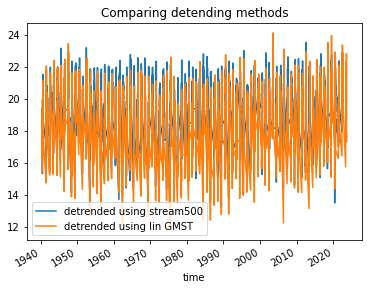

In [76]:
t2m_decom["T2M_dynamic"].mean(dim=("latitude", "longitude")).plot(label="detrended using stream500")
t2m_detrended_lin_GMST.mean(dim=("latitude", "longitude")).plot(label="detrended using lin GMST")

plt.legend()
plt.title("Comparing detending methods")


In [77]:
# plot trends per gridpoint

In [108]:
## taking trend per gridpoint when t is detrended using GMST

t2m_detrended_lin_GMST

t2m_detrended_lin_GMST_year =t2m_detrended_lin_GMST.groupby(t2m_detrended_lin_GMST.time.dt.year).mean(dim="time")

reg_coefs = np.empty(t2m_detrended_lin_GMST_year.shape[1:]) #create empty numpy array to save the lin regr coefs in 

x = np.arange(0,t2m_detrended_lin_GMST_year.year.shape[0],1).reshape(-1,1) #get the number of timesteps 

for i, lat in enumerate(t2m_detrended_lin_GMST_year.latitude): #loop over the gridpoints 
    for j, lon in enumerate(t2m_detrended_lin_GMST_year.longitude):
        y = t2m_detrended_lin_GMST_year.sel(latitude=lat, longitude=lon) #get the t2m data for this gridpoint
        reg = LinearRegression().fit(x, y) #fit the regressor
        reg_coefs[i,j]=reg.coef_[0] #save the coef in the array

In [109]:
### taking trend of dynamical t (as by decomposition using stream500)
dynamic_t = t2m_decom["T2M_dynamic"] 
dynamic_t_per_year =dynamic_t.groupby(dynamic_t.time.dt.year).mean(dim="time")

reg_coefs_tdyn = np.empty(dynamic_t_per_year.shape[1:]) #create empty numpy array to save the lin regr coefs in 

x = np.arange(0,dynamic_t_per_year.year.shape[0],1).reshape(-1,1) #get the number of timesteps 

for i, lat in enumerate(dynamic_t.latitude): #loop over the gridpoints 
    for j, lon in enumerate(dynamic_t.longitude):
        y = dynamic_t_per_year.sel(latitude=lat, longitude=lon) #get the t2m data for this gridpoint
        reg = LinearRegression().fit(x, y) #fit the regressor
        reg_coefs_tdyn[i,j]=reg.coef_[0] #save the coef in the array

/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.1

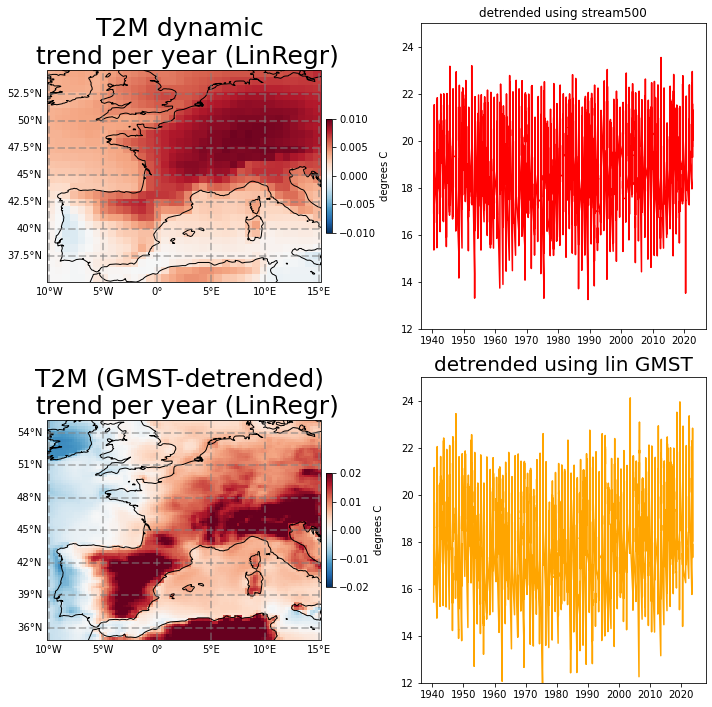

In [130]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches


### PLOT

fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(6, 6)


### 

ax1 = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
cs = ax1.pcolormesh(dynamic_t.longitude, dynamic_t.latitude, reg_coefs_tdyn,
                 transform=ccrs.PlateCarree(), vmin=-0.01, vmax=0.01, cmap=cmap, edgecolors = 'None') # vmin=-2, vmax=2,

ax1.coastlines()
ax1.set_title(f"T2M dynamic \n trend per year (LinRegr)", fontsize=25)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
fig.colorbar(cs, ax=ax1, fraction=0.02, pad=0.02, label="degrees C")

####

ax2 = fig.add_subplot(gs[0:3, 3:6])
ax2.plot(t2m_decom["T2M_dynamic"].time, t2m_decom["T2M_dynamic"].mean(dim=("latitude", "longitude")),
         c="red")

ax2.set_title("detrended using stream500")
ax2.set_ylim(12,25)

##
ax3 = fig.add_subplot(gs[3:6, 0:3], projection=ccrs.PlateCarree())
cs = ax3.pcolormesh(t2m_detrended_lin_GMST_year.longitude, t2m_detrended_lin_GMST_year.latitude, reg_coefs,
                 transform=ccrs.PlateCarree(), vmin=-0.02, vmax=0.02, cmap=cmap, edgecolors = 'None') # vmin=-2, vmax=2,

ax3.coastlines()
ax3.set_title(f"T2M (GMST-detrended) \n trend per year (LinRegr)", fontsize=25)
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
fig.colorbar(cs, ax=ax3, fraction=0.02, pad=0.02, label="degrees C")


##


ax4 = fig.add_subplot(gs[3:6, 3:6])
ax4.plot(t2m_detrended_lin_GMST.time, t2m_detrended_lin_GMST.mean(dim=("latitude", "longitude")),
         c="orange")
ax4.set_title("detrended using lin GMST", fontsize=20)
ax4.set_ylim(12,25)



fig.tight_layout()

# comparing different temperature detrended by dynamical decomposition

#### 1) Tdynamic

- Temperature as reconstructed by using stream500 as timeseries 

#### 2) T-thermodynamic
- Temperature minus Temp_thermodynamic as reconstructed by using GMST timeseries

#### 3) Temp - GMST 
- Temperature minus GMST 5y lowess

In [13]:
ls /home/thappe/data/T2M_decomposition

 JJA/
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_Tdyn_90thPctl_15d.nc'
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_temp_only.nc'
'T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_90thpercentile.nc'
'T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'


In [15]:
t2m_decomped_file = "T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc"

t2m_decom_JJAS = xr.open_dataset(f"{data_path}/T2M_decomposition/{t2m_decomped_file}")

In [16]:
t2m_decom_JJAS

<xarray.Dataset>
Dimensions:                (time: 6468, latitude: 28, longitude: 36)
Coordinates:
  * time                   (time) datetime64[ns] 1940-06-23T11:00:00 ... 2023...
  * longitude              (longitude) float64 -9.844 -9.141 ... 14.06 14.77
  * latitude               (latitude) float64 35.44 36.14 36.84 ... 53.68 54.39
Data variables:
    T2M_thermodynamic_std  (time, latitude, longitude) float64 ...
    T2M_dynamical_std      (time, latitude, longitude) float64 ...
    T2M_dynamic            (time, latitude, longitude) float64 ...
    T2M_combined           (time, latitude, longitude) float64 ...
    optimal_lambda         (latitude, longitude) float64 ...
    MSE                    (latitude, longitude) float64 ...
    R2                     (latitude, longitude) float64 ...
Attributes:
    description:  Ridge regression to decompose T2M into thermo and dynamical...

In [36]:
## see how I calculated the mean and std and do that here:

T2M_file = "1940-2023_T2M_westEU_June23-JA-Sept7_LENTISGRID.nc"
t2m = xr.open_dataset(f"{data_path}{T2M_file}")["t2m"] - 273.15
t2m = t2m.rename({"lat":"latitude", "lon":"longitude"})
# latitudes = t2m.lat
# longitudes = t2m.lon
t2m_mean = t2m.mean(dim="time") #.rename({"lat":"latitude", "lon":"longitude"})
t2m_std = t2m.std(dim="time") #.rename({"lat":"latitude", "lon":"longitude"})


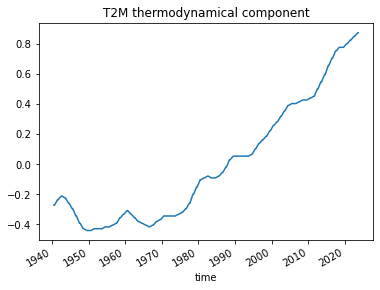

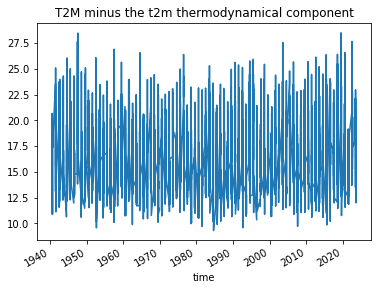

<Figure size 432x288 with 0 Axes>

In [41]:
T2M_thermodynamical = (t2m_decom_JJAS["T2M_thermodynamic_std"] * t2m_std ) #+ t2m_mean  #convert to T2M values
T2M_thermodynamical.sel(latitude=50, longitude=5, method="nearest").plot()
plt.title("T2M thermodynamical component")
plt.show()
plt.clf()

T2M_minus_thermo = t2m - T2M_thermodynamical
T2M_minus_thermo.sel(latitude=50, longitude=5, method="nearest").plot()
plt.title("T2M minus the t2m thermodynamical component")
plt.show()
plt.clf()



## comparing number 2 and number 3

In [51]:
yearly_GMST = pd.read_csv(f"{data_path}NASA_GMST.csv", delimiter=";", skiprows=1, index_col=0)
ny=np.unique(T2M_thermodynamical.time.dt.year).shape[0]
yearly_GMST_5y = yearly_GMST["Lowess(5)"][-ny:]

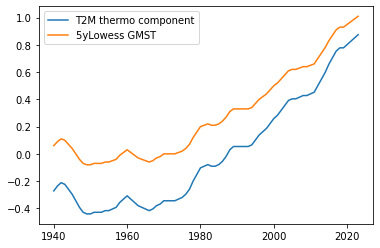

In [66]:
plt.plot(T2M_thermodynamical.time.dt.year, T2M_thermodynamical.sel(latitude=50, longitude=5, method="nearest"), 
         label="T2M thermo component")
plt.plot(np.unique(T2M_thermodynamical.time.dt.year), yearly_GMST_5y, label="5yLowess GMST")

#yearly_GMST_5y.plot(label="5yLowess GMST")
#T2M_thermodynamical.sel(latitude=50, longitude=5, method="nearest").plot(label="T2M thermo component")
plt.legend()

so why not just remove the GMST directly? what is the wrong approach with this? or take liike 10/20y smoothening and remove that?

In [83]:
T2M_minus_5yGMST = t2m.copy()

for t in range(t2m.shape[0]):
    year = t2m[t].time.dt.year
    gmst_year = yearly_GMST_5y[int(year)]
    T2M_minus_5yGMST[t] = t2m[t] - gmst_year
    
#T2M_minus_5yGMST 

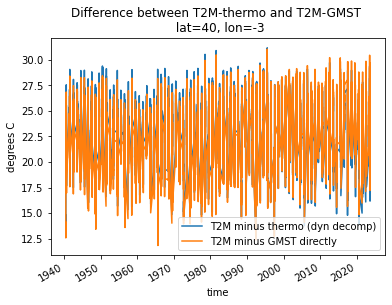

Text(0.5, 1.0, 'Difference between T2M-thermo and T2M-GMST \n lat=40, lon=-3')

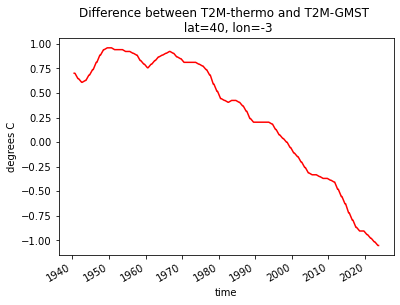

In [191]:
T2M_minus_thermo = t2m - T2M_thermodynamical

lat=40
lon=-3

ex1 = T2M_minus_thermo.sel(latitude=lat, longitude=lon, method="nearest")
ex1.plot(label="T2M minus thermo (dyn decomp)")
ex2 = T2M_minus_5yGMST.sel(latitude=lat, longitude=lon, method="nearest")
ex2.plot(label="T2M minus GMST directly")
plt.ylabel("degrees C")
plt.title(f"Difference between T2M-thermo and T2M-GMST \n lat={lat}, lon={lon}")

plt.legend()
plt.show()
plt.clf()

ex3 = ex1 - ex2 
ex3.plot(label = "difference in degrees C", c="red")
plt.ylabel("degrees C")
plt.title(f"Difference between T2M-thermo and T2M-GMST \n lat={lat}, lon={lon}")

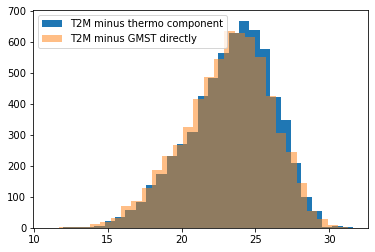

In [190]:

binwidth = 0.7

plt.hist(ex1, bins=np.arange(int(ex1.min()), int(ex1.max()) + binwidth, binwidth), 
         label="T2M minus thermo component")
plt.hist(ex2, bins=np.arange(int(ex2.min()), int(ex2.max()) + binwidth, binwidth),
         label="T2M minus GMST directly", alpha=0.5)
plt.legend()

so I don't see so much difference here? 

what if I plot the trend for each gridpoint _after_ detrending?

In [175]:
#T2M_minus_thermo,  T2M_minus_5yGMST 

In [179]:
## taking trend per gridpoint when t is detrended using GMST

T2M_minus_5yGMST

T2M_minus_5yGMST_year = T2M_minus_5yGMST.groupby(T2M_minus_5yGMST.time.dt.year).mean(dim="time")

reg_coefs = np.empty(T2M_minus_5yGMST_year.shape[1:]) #create empty numpy array to save the lin regr coefs in 

x = np.arange(0,T2M_minus_5yGMST_year.year.shape[0],1).reshape(-1,1) #get the number of timesteps 

for i, lat in enumerate(T2M_minus_5yGMST.latitude): #loop over the gridpoints 
    for j, lon in enumerate(T2M_minus_5yGMST.longitude):
        y = T2M_minus_5yGMST_year.sel(latitude=lat, longitude=lon) #get the t2m data for this gridpoint
        reg = LinearRegression().fit(x, y) #fit the regressor
        reg_coefs[i,j]=reg.coef_[0] #save the coef in the array

In [178]:
### taking trend of thermodybamical t (as by decomposition using stream500 and GMST)
T2M_minus_thermo

thermo_t_per_year =T2M_minus_thermo.groupby(T2M_minus_thermo.time.dt.year).mean(dim="time")

reg_coefs_tthermo = np.empty(thermo_t_per_year.shape[1:]) #create empty numpy array to save the lin regr coefs in 

x = np.arange(0,thermo_t_per_year.year.shape[0],1).reshape(-1,1) #get the number of timesteps 

for i, lat in enumerate(T2M_minus_thermo.latitude): #loop over the gridpoints 
    for j, lon in enumerate(T2M_minus_thermo.longitude):
        y = thermo_t_per_year.sel(latitude=lat, longitude=lon) #get the t2m data for this gridpoint
        reg = LinearRegression().fit(x, y) #fit the regressor
        reg_coefs_tthermo[i,j]=reg.coef_[0] #save the coef in the array

/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.1

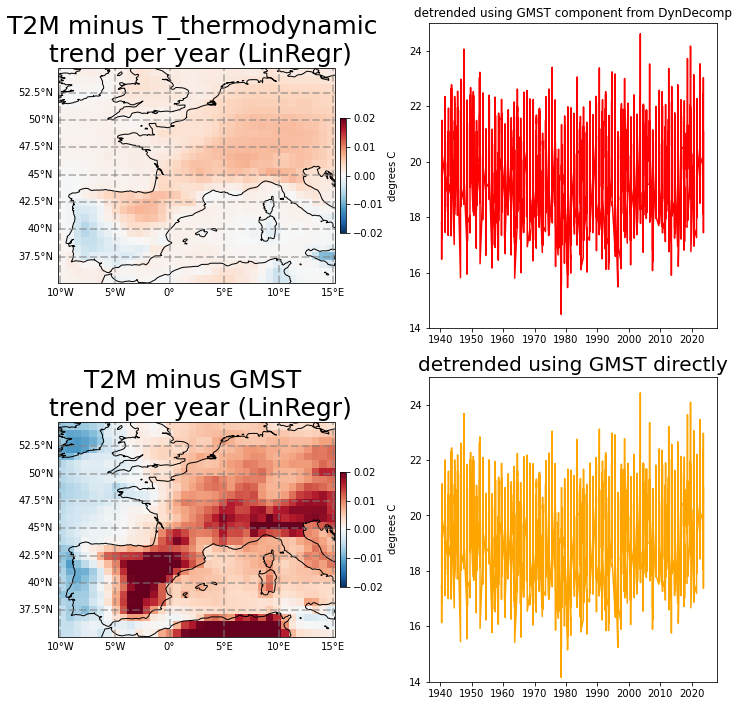

In [187]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches


### PLOT

fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(6, 6)

cmap="RdBu_r"
### 

ax1 = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
cs = ax1.pcolormesh(T2M_minus_thermo.longitude, T2M_minus_thermo.latitude, reg_coefs_tthermo,
                 transform=ccrs.PlateCarree(), vmin=-0.02, vmax=0.02, cmap=cmap, edgecolors = 'None') # vmin=-2, vmax=2,

ax1.coastlines()
ax1.set_title(f"T2M minus T_thermodynamic \n trend per year (LinRegr)", fontsize=25)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
fig.colorbar(cs, ax=ax1, fraction=0.02, pad=0.02, label="degrees C")

####

ax2 = fig.add_subplot(gs[0:3, 3:6])
ax2.plot(T2M_minus_thermo.time, T2M_minus_thermo.mean(dim=("latitude", "longitude")),
         c="red")

ax2.set_title("detrended using GMST component from DynDecomp")
ax2.set_ylim(14,25)

##
ax3 = fig.add_subplot(gs[3:6, 0:3], projection=ccrs.PlateCarree())
cs = ax3.pcolormesh(T2M_minus_5yGMST_year.longitude, T2M_minus_5yGMST_year.latitude, reg_coefs,
                 transform=ccrs.PlateCarree(), vmin=-0.02, vmax=0.02, cmap=cmap, edgecolors = 'None') # vmin=-2, vmax=2,

ax3.coastlines()
ax3.set_title(f"T2M minus GMST \n trend per year (LinRegr)", fontsize=25)
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
fig.colorbar(cs, ax=ax3, fraction=0.02, pad=0.02, label="degrees C")


##


ax4 = fig.add_subplot(gs[3:6, 3:6])
ax4.plot(T2M_minus_5yGMST.time, T2M_minus_5yGMST.mean(dim=("latitude", "longitude")),
         c="orange")
ax4.set_title("detrended using GMST directly", fontsize=20)
ax4.set_ylim(14,25)



fig.tight_layout()

## how about the reconstruction of the extremes when looking at dynamical decompostion?

In [110]:
combined_from_dyndecomp = t2m_decom_JJAS["T2M_combined"]
R2 = t2m_decom_JJAS["R2"]

In [107]:
t2m_decom_JJAS

<xarray.Dataset>
Dimensions:                (time: 6468, latitude: 28, longitude: 36)
Coordinates:
  * time                   (time) datetime64[ns] 1940-06-23T11:00:00 ... 2023...
  * longitude              (longitude) float64 -9.844 -9.141 ... 14.06 14.77
  * latitude               (latitude) float64 35.44 36.14 36.84 ... 53.68 54.39
Data variables:
    T2M_thermodynamic_std  (time, latitude, longitude) float64 ...
    T2M_dynamical_std      (time, latitude, longitude) float64 ...
    T2M_dynamic            (time, latitude, longitude) float64 ...
    T2M_combined           (time, latitude, longitude) float64 ...
    optimal_lambda         (latitude, longitude) float64 nan nan nan ... nan nan
    MSE                    (latitude, longitude) float64 0.8369 ... 0.6713
    R2                     (latitude, longitude) float64 0.2997 ... 0.5493
Attributes:
    description:  Ridge regression to decompose T2M into thermo and dynamical...

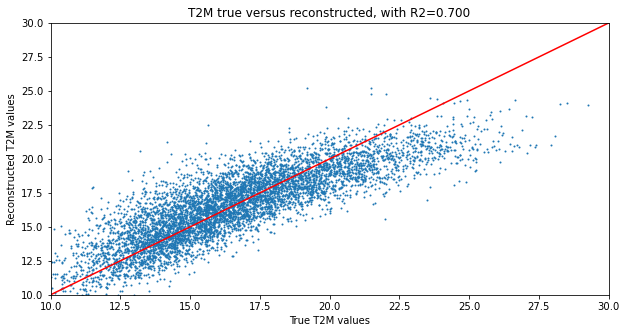

In [128]:
lower_lim = 10
upper_lim = 30 

fig, ax = plt.subplots()

plt.scatter(t2m.sel(latitude=50, longitude=5, method="nearest"), 
         combined_from_dyndecomp.sel(latitude=50, longitude=5, method="nearest"),
           s=1)
plt.plot([lower_lim,upper_lim], [lower_lim,upper_lim], 'r-')
plt.ylabel("Reconstructed T2M values")
plt.xlabel("True T2M values")
plt.xlim(lower_lim,upper_lim)
plt.ylim(lower_lim,upper_lim)
R2_here = float(R2.sel(latitude=50, longitude=5, method="nearest"))

plt.title(f"T2M true versus reconstructed, with R2={R2_here:.3f}")

plt.rcParams["figure.figsize"] = (10,5)


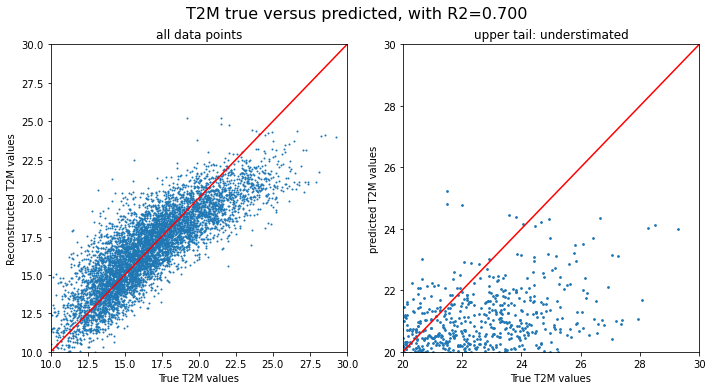

In [149]:
fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(8, 8)


### 
lower_lim = 10
upper_lim = 30 

ax1 = fig.add_subplot(gs[0:4, 0:4])
ax1.scatter(t2m.sel(latitude=50, longitude=5, method="nearest"), 
         combined_from_dyndecomp.sel(latitude=50, longitude=5, method="nearest"),
           s=1)
ax1.plot([lower_lim,upper_lim], [lower_lim,upper_lim], 'r-')
ax1.set_ylabel("Reconstructed T2M values")
ax1.set_xlabel("True T2M values")
ax1.set_xlim(lower_lim,upper_lim)
ax1.set_ylim(lower_lim,upper_lim)
R2_here = float(R2.sel(latitude=50, longitude=5, method="nearest"))

ax1.set_title(f"all data points")


lower_lim = 20
upper_lim = 30 

ax2 = fig.add_subplot(gs[0:4, 4:8])
ax2.scatter(t2m.sel(latitude=50, longitude=5, method="nearest"), 
         combined_from_dyndecomp.sel(latitude=50, longitude=5, method="nearest"),
           s=3)
ax2.plot([lower_lim,upper_lim], [lower_lim,upper_lim], 'r-')
ax2.set_ylabel("predicted T2M values")
ax2.set_xlabel("True T2M values")
ax2.set_xlim(lower_lim,upper_lim)
ax2.set_ylim(lower_lim,upper_lim)
R2_here = float(R2.sel(latitude=50, longitude=5, method="nearest"))

ax2.set_title(f"upper tail: understimated")

fig.suptitle(f"T2M true versus predicted, with R2={R2_here:.3f}", fontsize=16)
fig.tight_layout()


plotting histogram to see the distribution better

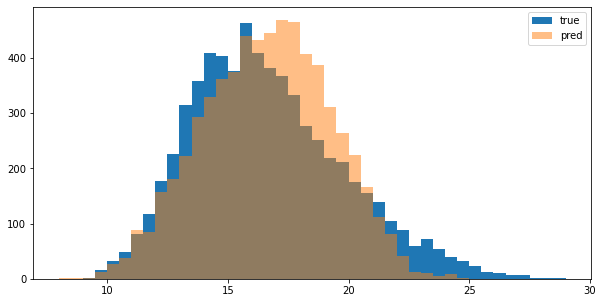

In [169]:
t2m_5_50 = t2m.sel(latitude=50, longitude=5, method="nearest")
t2m_pred_5_50=combined_from_dyndecomp.sel(latitude=50, longitude=5, method="nearest")


binwidth = 0.5

plt.hist(t2m_5_50, bins=np.arange(int(t2m_5_50.min()), int(t2m_5_50.max()) + binwidth, binwidth), label="true")
plt.hist(t2m_pred_5_50, bins=np.arange(int(t2m_pred_5_50.min()), int(t2m_pred_5_50.max()) + binwidth, binwidth),
         label="pred", alpha=0.5)
plt.legend()

## What is the difference in temperature (especially high temperatures) if I take original temperature - thermodynamic_temp vs dynamical_temp. 


In [192]:
T2M_minus_thermo
T2M_dynamic = t2m_decom_JJAS["T2M_dynamic"]

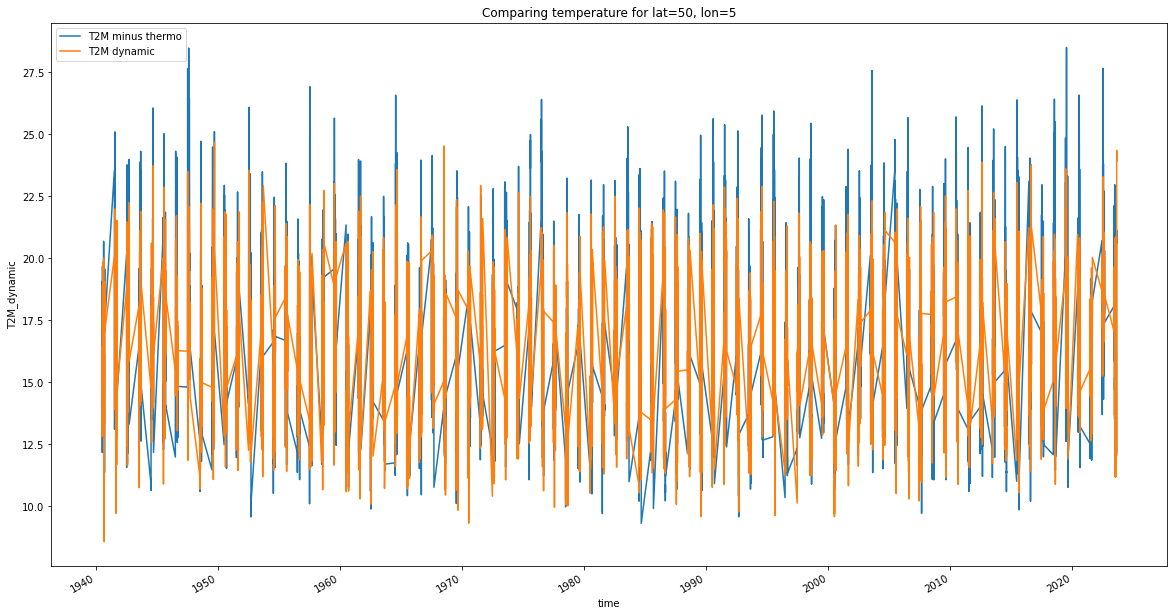

In [200]:
lat=50 #40
lon=5 #-3

T2M_minus_thermo.sel(latitude=lat, longitude=lon, method="nearest").plot(label="T2M minus thermo")
T2M_dynamic.sel(latitude=lat, longitude=lon, method="nearest").plot(label="T2M dynamic")
plt.title(f"Comparing temperature for lat={lat}, lon={lon}")
plt.legend()
plt.rcParams["figure.figsize"] = (20,10)


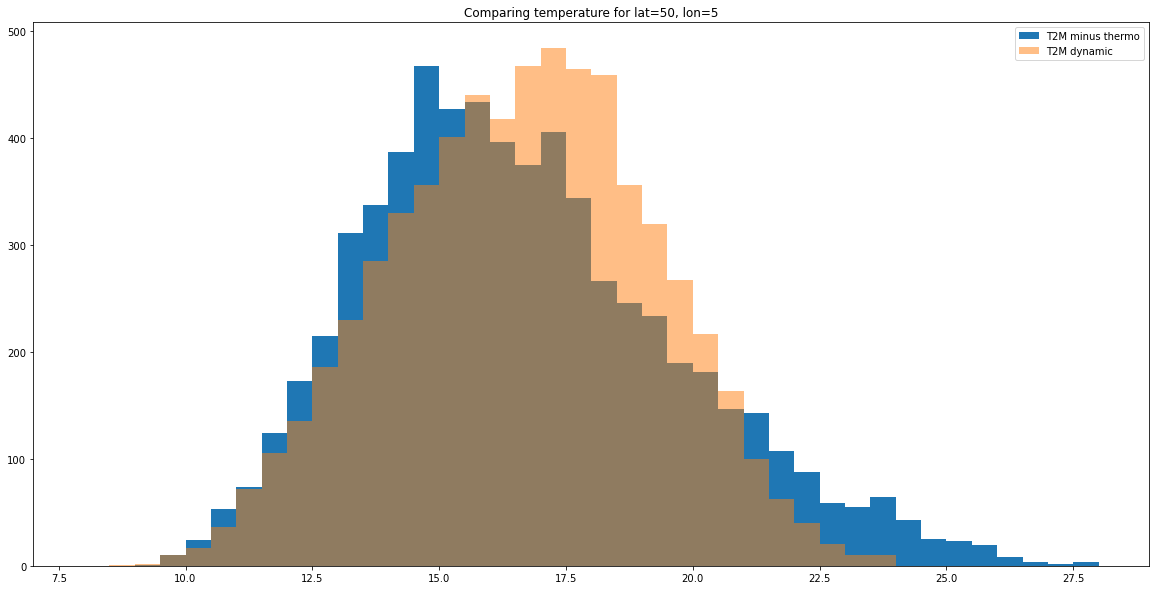

In [201]:
T2M_minus_thermo_here = T2M_minus_thermo.sel(latitude=lat, longitude=lon, method="nearest")
T2M_dynamic_here = T2M_dynamic.sel(latitude=lat, longitude=lon, method="nearest")

binwidth = 0.5

plt.hist(T2M_minus_thermo_here, 
         bins=np.arange(int(T2M_minus_thermo_here.min()), int(T2M_minus_thermo_here.max()) + binwidth, binwidth), 
         label="T2M minus thermo")
plt.hist(T2M_dynamic_here,
         bins=np.arange(int(T2M_dynamic_here.min()), int(T2M_dynamic_here.max()) + binwidth, binwidth),
         label="T2M dynamic", alpha=0.5)

plt.title(f"Comparing temperature for lat={lat}, lon={lon}")
plt.legend()

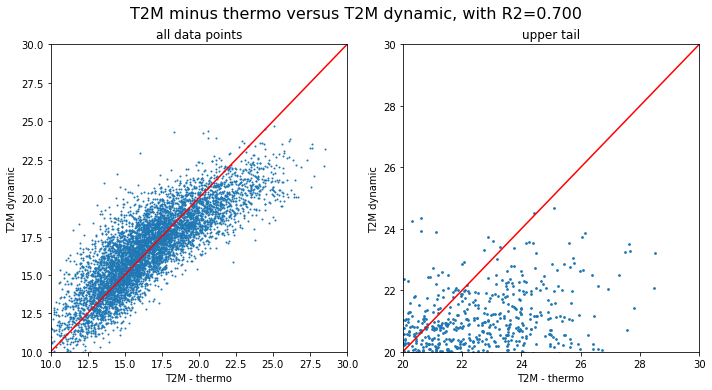

In [203]:
fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(8, 8)


### 
lower_lim = 10
upper_lim = 30 

ax1 = fig.add_subplot(gs[0:4, 0:4])
ax1.scatter(T2M_minus_thermo_here, T2M_dynamic_here,
           s=1)
ax1.plot([lower_lim,upper_lim], [lower_lim,upper_lim], 'r-')
ax1.set_ylabel("T2M dynamic")
ax1.set_xlabel("T2M - thermo")
ax1.set_xlim(lower_lim,upper_lim)
ax1.set_ylim(lower_lim,upper_lim)
R2_here = float(R2.sel(latitude=lat, longitude=lon, method="nearest"))

ax1.set_title(f"all data points")


lower_lim = 20
upper_lim = 30 

ax2 = fig.add_subplot(gs[0:4, 4:8])
ax2.scatter(T2M_minus_thermo_here, T2M_dynamic_here,
           s=3)
ax2.plot([lower_lim,upper_lim], [lower_lim,upper_lim], 'r-')
ax2.set_ylabel("T2M dynamic")
ax2.set_xlabel("T2M - thermo")
ax2.set_xlim(lower_lim,upper_lim)
ax2.set_ylim(lower_lim,upper_lim)
R2_here = float(R2.sel(latitude=50, longitude=5, method="nearest"))

ax2.set_title(f"upper tail")

fig.suptitle(f"T2M minus thermo versus T2M dynamic, with R2={R2_here:.3f}", fontsize=16)
fig.tight_layout()

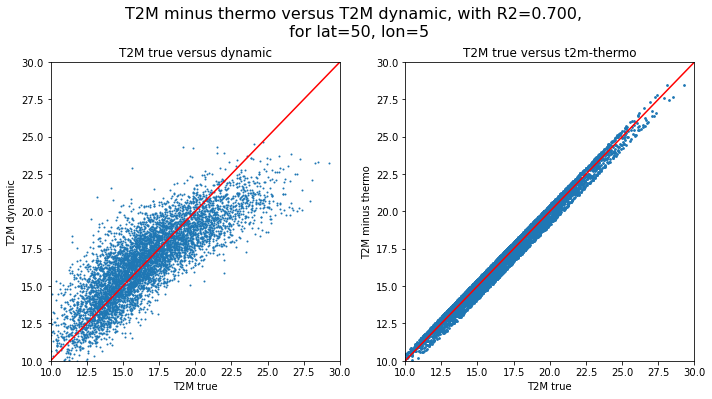

In [207]:
fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(8, 8)


t2m_here = t2m.sel(latitude=lat, longitude=lon, method="nearest")

### 
lower_lim = 10
upper_lim = 30 

ax1 = fig.add_subplot(gs[0:4, 0:4])
ax1.scatter(t2m_here, T2M_dynamic_here,
           s=1)
ax1.plot([lower_lim,upper_lim], [lower_lim,upper_lim], 'r-')
ax1.set_ylabel("T2M dynamic")
ax1.set_xlabel("T2M true")
ax1.set_xlim(lower_lim,upper_lim)
ax1.set_ylim(lower_lim,upper_lim)
R2_here = float(R2.sel(latitude=lat, longitude=lon, method="nearest"))

ax1.set_title(f"T2M true versus dynamic")

###
ax2 = fig.add_subplot(gs[0:4, 4:8])
ax2.scatter(t2m_here, T2M_minus_thermo_here,
           s=3)
ax2.plot([lower_lim,upper_lim], [lower_lim,upper_lim], 'r-')
ax2.set_ylabel("T2M minus thermo")
ax2.set_xlabel("T2M true")
ax2.set_xlim(lower_lim,upper_lim)
ax2.set_ylim(lower_lim,upper_lim)
R2_here = float(R2.sel(latitude=50, longitude=5, method="nearest"))

ax2.set_title(f"T2M true versus t2m-thermo")

fig.suptitle(f"T2M minus thermo versus T2M dynamic, with R2={R2_here:.3f}, \n for lat={lat}, lon={lon}", 
             fontsize=16)
fig.tight_layout()